<a href="https://colab.research.google.com/github/AlanGVEGA/DataScienceProjectCyberSecurityTraffic/blob/main/Train_Test_Dataset_UNSW_NB15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DataXperience — UNSW-NB15- Project**
## **Análisis exploratorio, calidad de datos y estadística descriptiva**

**Dataset:** UNSW-NB15  

**Autores:** Alan Gabriel Vega Tinjaca - Angelica Vanessa Castro

**Curso:** DataXperience  

**Profesora:**

**Notebook principal colaborativo Main**

**Fecha-actualizacion:** September 18, 2026

### **Pregunta principal del proyecto**
> *¿Qué características del tráfico de red del dataset UNSW-NB15 permiten distinguir entre tráfico normal y tráfico malicioso, y cuáles presentan mayor capacidad para explicar posteriormente la presencia de ataques?*

### **Preguntas de apoyo**
1. ¿Cómo se distribuyen las conexiones normales y maliciosas y las categorías de ataque?
2. ¿Qué diferencias descriptivas existen entre tráfico normal y malicioso en duración, paquetes, bytes, tasas y tiempos?
3. ¿Qué variables muestran patrones o diferencias relevantes entre ambos grupos?
4. **Módulo 3:** ¿Hasta qué punto estas características pueden utilizarse en un modelo para clasificar tráfico de red?

### Reglas para nuestro ambiente
- Los archivos **raw no se modifican**.
- Para Módulos 1 y 2 se trabaja principalmente con `UNSW_NB15_training-set.csv`.
- `UNSW_NB15_testing-set.csv` se reserva para evaluación posterior en Módulo 3.
- Ninguna fila, variable, valor faltante, duplicado u outlier se elimina sin justificación documentada.
- Cada bloque sigue: **Purpose → Code → Result → Interpretation → Decision**. (Si entra en lo posible porfa)

---


# MODULO 1 — Fundamentos, contexto y herramientas



---

## 0. Contexto y procedencia del dataset

La documentación suministrada describe UNSW-NB15 como tráfico generado en el Cyber Range Lab de UNSW Canberra mediante una combinación de actividad normal moderna y ataques sintéticos contemporáneos. Incluye nueve familias de ataque: **Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode y Worms**.

Particiones documentadas:
- **Training:** 175,341 registros.
- **Testing:** 82,332 registros.
- La partición de entrenamiento utilizada aquí contiene **45 columnas**, incluyendo `attack_cat` y `label`.
- `label = 0` representa tráfico normal y `label = 1` representa ataque.

> `NUSW-NB15_features.csv` documenta las características del dataset original. La partición training/testing usa un esquema preparado para clasificación, por lo que no se debe asumir correspondencia 1:1 por nombre sin comprobarla.

## 1. Configuración del entorno

**Purpose:** preparar Google Colab y las librerías necesarias sin modificar los datos.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print("Entorno listo.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno listo.


### 1.1 Localización de archivos en Drive

Esta celda busca y asigna las respectivas rutas a sus variables para empezar el lab con estas mismas

In [ ]:
'''
Revisa bien que el path coincida con la ruta en donde tengas el proyecto, En este caso lo tengo guardado dentro de la carpeta DataXperience_UNSW-NB15.
con ruta de /content/drive/MyDrive/....
Asegurate que lo tengas guardado con el mismo nombre y lugar, por ejemplo revisa si lo tienes en compartidos como por ejemplo:
/content/drive/shared-with-me/DataXperience_UNSW-NB15/.....

una forma para saber con exactitud la ruta de tus archivos y tambien de tenerlos a mano pra asignar dataset a variables seria buscar dentro
de tu drive abrir la carpeta y seleccionar el archivo que quieres o carpeta, le das click al link y ahi tienes tu ruta, lo unico que copiaras y pegaras
sera despues del /content/.....

Crea una copia de este si quieres matener este de prueba y usar el tuyo propio desde tu propio entorno
'''

TRAIN_PATH = Path('/content/drive/MyDrive/DataXperience_UNSW-NB15/01. Dataset/UNSW-NB15 dataset/CSV Files/Training and Testing Sets/UNSW_NB15_training-set.csv')
TEST_PATH = Path('/content/drive/MyDrive/DataXperience_UNSW-NB15/01. Dataset/UNSW-NB15 dataset/CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv')
FEATURES_PATH = Path('/content/drive/MyDrive/DataXperience_UNSW-NB15/01. Dataset/UNSW-NB15 dataset/CSV Files/NUSW-NB15_features.csv')

print("TRAIN   :", TRAIN_PATH)
print("TEST    :", TEST_PATH)
print("FEATURES:", FEATURES_PATH)

TRAIN   : /content/drive/MyDrive/DataXperience_UNSW-NB15/01. Dataset/UNSW-NB15 dataset/CSV Files/Training and Testing Sets/UNSW_NB15_training-set.csv
TEST    : /content/drive/MyDrive/DataXperience_UNSW-NB15/01. Dataset/UNSW-NB15 dataset/CSV Files/Training and Testing Sets/UNSW_NB15_testing-set.csv
FEATURES: /content/drive/MyDrive/DataXperience_UNSW-NB15/01. Dataset/UNSW-NB15 dataset/CSV Files/NUSW-NB15_features.csv


## 2. Carga del dataset

**Purpose:** cargar únicamente la partición de entrenamiento para Módulos 1 y 2.

El testing set **no se analiza todavía**, para mantenerlo separado de las decisiones exploratorias y del futuro modelado.

In [ ]:
df = pd.read_csv(TRAIN_PATH)
features_reference = pd.read_csv(FEATURES_PATH, encoding='latin1')

print("Training cargado correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Training cargado correctamente.
Filas: 175,341
Columnas: 45


## 3. Data Understanding — inspección inicial



### 3.1 Dimensiones, primeras filas y columnas

**Purpose:** confirmar que el archivo cargado corresponde a la partición esperada y entender su estructura antes de transformarlo.

In [ ]:
EXPECTED_TRAIN_ROWS = 175_341

print("Dimensiones:", df.shape)
print("Coincide con las 175,341 filas documentadas:", df.shape[0] == EXPECTED_TRAIN_ROWS)

display(df.head())

print("\nColumnas:")
print(df.columns.tolist())

Dimensiones: (175341, 45)
Coincide con las 175,341 filas documentadas: True


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.1215,tcp,-,FIN,6,4,258,172,74.0875,252,254,"14,158.9424","8,495.3652",0,0,24.2956,8.3750,30.1775,11.8306,255,621772692,2202533631,255,0.0000,0.0000,0.0000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.6499,tcp,-,FIN,14,38,734,42014,78.4734,62,252,"8,395.1123","503,571.3125",2,17,49.9150,15.4329,61.4269,"1,387.7783",255,1417884146,3077387971,255,0.0000,0.0000,0.0000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.6231,tcp,-,FIN,8,16,364,13186,14.1702,62,252,"1,572.2719","60,929.2305",1,6,231.8756,102.7372,"17,179.5869","11,420.9262",255,2116150707,2963114973,255,0.1119,0.0615,0.0504,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.6816,tcp,ftp,FIN,12,12,628,770,13.6771,62,252,"2,740.1790","3,358.6221",1,3,152.8765,90.2357,259.0802,"4,991.7847",255,1107119177,1047442890,255,0.0000,0.0000,0.0000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.4495,tcp,-,FIN,10,6,534,268,33.3738,254,252,"8,561.4990","3,987.0598",2,1,47.7503,75.6596,"2,415.8376",115.8070,255,2436137549,1977154190,255,0.1284,0.0711,0.0572,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0



Columnas:
['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


### 3.2 Tipos de datos y uso de memoria

***Interpretación:*** El dataset de entrenamiento contiene 45 variables: 41 numéricas y 4 categóricas. Pandas identifica 30 variables int64, 11 float64 y 4 object: proto, service, state y attack_cat. La variable label corresponde al objetivo binario almacenado como entero, mientras que attack_cat representa la categoría de tráfico. No se identificaron valores nulos durante esta inspección.


In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

### 3.3 Verificación de variables objetivo

- `attack_cat`: categoría de tráfico/ataque.
- `label`: etiqueta binaria, **0 = normal, 1 = ataque**.

In [ ]:
required_targets = {'attack_cat', 'label'}
missing_targets = required_targets - set(df.columns)

if missing_targets:
    raise ValueError(f"Faltan variables objetivo esperadas: {missing_targets}")

print("Variables objetivo encontradas correctamente.")
display(df[['attack_cat', 'label']].head(10))

Variables objetivo encontradas correctamente.


,attack_cat,label
0,Normal,0
1,Normal,0
2,Normal,0
3,Normal,0
4,Normal,0
5,Normal,0
6,Normal,0
7,Normal,0
8,Normal,0
9,Normal,0


## 4. Diccionario de datos

**Purpose:** utilizar el archivo oficial de features como referencia semántica y construir, por separado, un inventario del esquema real del training set.

No se hace un `merge` automático porque los nombres del esquema original y del training preparado no son idénticos en todos los casos.

In [ ]:
features_reference.columns = (
    features_reference.columns
    .str.strip()
    .str.lower()
)

display(features_reference.head(10))
print("Variables documentadas en la referencia:", len(features_reference))

,no.,name,type,description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


Variables documentadas en la referencia: 49


In [ ]:
schema = pd.DataFrame({
    'variable': df.columns,
    'dtype_pandas': [str(df[col].dtype) for col in df.columns],
    'non_null': [df[col].notna().sum() for col in df.columns],
    'nulls': [df[col].isna().sum() for col in df.columns],
    'unique_values': [df[col].nunique(dropna=False) for col in df.columns]
})

def conceptual_type(col):
    if col == 'label':
        return 'binary target'
    if col == 'attack_cat':
        return 'categorical target'
    if pd.api.types.is_numeric_dtype(df[col]):
        return 'numeric'
    return 'categorical'

schema['conceptual_type'] = [conceptual_type(col) for col in df.columns]

display(schema)

,variable,dtype_pandas,non_null,nulls,unique_values,conceptual_type
0,id,int64,175341,0,175341,numeric
1,dur,float64,175341,0,74039,numeric
2,proto,object,175341,0,133,categorical
3,service,object,175341,0,13,categorical
4,state,object,175341,0,9,categorical
5,spkts,int64,175341,0,480,numeric
6,dpkts,int64,175341,0,443,numeric
7,sbytes,int64,175341,0,7214,numeric
8,dbytes,int64,175341,0,6660,numeric
9,rate,float64,175341,0,76991,numeric


### Trabajo colaborativo — diccionario

Completar como equipo una tabla con:

`variable | descripción | tipo conceptual | rol | interpretación en ciberseguridad`

**División sugerida:**
- Persona A: variables numéricas.
- Persona B: categóricas + `attack_cat` + `label`.
- Ambos revisan la versión consolidada.

No interpretar una variable solo por su nombre si la documentación no es suficiente.

## 5. Data Quality Assessment

**Purpose:** diagnosticar problemas antes de limpiar.

En esta sección **NO se elimina ni reemplaza nada**.

### 5.1 Valores faltantes

In [ ]:
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean() * 100
}).sort_values('missing_count', ascending=False)

display(missing_summary)

print("Columnas con al menos un valor faltante:",
      (missing_summary['missing_count'] > 0).sum())

,missing_count,missing_pct
id,0,0.0000
dur,0,0.0000
proto,0,0.0000
service,0,0.0000
state,0,0.0000
spkts,0,0.0000
dpkts,0,0.0000
sbytes,0,0.0000
dbytes,0,0.0000
rate,0,0.0000


Columnas con al menos un valor faltante: 0


### 5.2 Duplicados exactos

Un duplicado no se elimina automáticamente. Primero hay que determinar si representa un error de registro o un evento de red repetido legítimamente.

In [ ]:
duplicate_count = df.duplicated().sum()
duplicate_pct = duplicate_count / len(df) * 100

print(f"Duplicados exactos: {duplicate_count:,}")
print(f"Porcentaje: {duplicate_pct:.4f}%")

Duplicados exactos: 0
Porcentaje: 0.0000%


### 5.3 Cardinalidad y variables constantes o casi constantes

In [ ]:
cardinality = df.nunique(dropna=False).sort_values().to_frame('unique_values')
display(cardinality)

print("\nVariables con un único valor:")
display(cardinality[cardinality['unique_values'] == 1])

,unique_values
is_sm_ips_ports,2
label,2
is_ftp_login,4
ct_ftp_cmd,4
ct_state_ttl,5
dttl,6
dwin,7
state,9
attack_cat,10
ct_flw_http_mthd,11



Variables con un único valor:


,unique_values


### 5.4 Variables categóricas

**Purpose:** identificar categorías, valores poco frecuentes, símbolos especiales e inconsistencias de representación.

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables categóricas:", categorical_cols)

for col in categorical_cols:
    print(f"\n{'='*70}")
    print(f"{col} — {df[col].nunique(dropna=False)} valores únicos")
    display(df[col].value_counts(dropna=False).head(25).to_frame('count'))

Variables categóricas: ['proto', 'service', 'state', 'attack_cat']

proto — 133 valores únicos


,count
proto,
tcp,79946
udp,63283
unas,12084
arp,2859
ospf,2595
sctp,1150
any,300
gre,225
ipv6,201



service — 13 valores únicos


,count
service,
-,94168
dns,47294
http,18724
smtp,5058
ftp-data,3995
ftp,3428
ssh,1302
pop3,1105
dhcp,94



state — 9 valores únicos


,count
state,
INT,82275
FIN,77825
CON,13152
REQ,1991
RST,83
ECO,12
PAR,1
URN,1
no,1



attack_cat — 10 valores únicos


,count
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133


### 5.5 Distribución de `label` y `attack_cat`

**Importante:** esta distribución describe la partición del dataset. No debe interpretarse automáticamente como prevalencia de ataques en redes reales.

In [ ]:
label_distribution = pd.DataFrame({
    'count': df['label'].value_counts(dropna=False),
    'percentage': df['label'].value_counts(normalize=True, dropna=False) * 100
})
display(label_distribution)

attack_distribution = pd.DataFrame({
    'count': df['attack_cat'].value_counts(dropna=False),
    'percentage': df['attack_cat'].value_counts(normalize=True, dropna=False) * 100
})
display(attack_distribution)

,count,percentage
label,,
1,119341,68.0622
0,56000,31.9378


,count,percentage
attack_cat,,
Normal,56000,31.9378
Generic,40000,22.8127
Exploits,33393,19.0446
Fuzzers,18184,10.3706
DoS,12264,6.9944
Reconnaissance,10491,5.9832
Analysis,2000,1.1406
Backdoor,1746,0.9958
Shellcode,1133,0.6462


In [ ]:
attack_label_table = pd.crosstab(
    df['attack_cat'],
    df['label'],
    margins=True
)

display(attack_label_table)

label,0,1,All
attack_cat,,,
Analysis,0,2000,2000
Backdoor,0,1746,1746
DoS,0,12264,12264
Exploits,0,33393,33393
Fuzzers,0,18184,18184
Generic,0,40000,40000
Normal,56000,0,56000
Reconnaissance,0,10491,10491
Shellcode,0,1133,1133


### 5.6 Estadística descriptiva inicial de variables numéricas

En esta fase sirve como diagnóstico. La interpretación estadística formal pertenece al Módulo 2. El percentil 99 ayuda a observar colas largas sin asumir que los valores extremos son errores.

In [ ]:
numeric_summary = (
    df.select_dtypes(include=np.number)
      .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
      .T
)

display(numeric_summary)

,count,mean,std,min,1%,25%,50%,75%,99%,max
id,"175,341.0000","87,671.0000","50,616.7311",1.0000,"1,754.4000","43,836.0000","87,671.0000","131,506.0000","173,587.6000","175,341.0000"
dur,"175,341.0000",1.3594,6.4802,0.0000,0.0000,0.0000,0.0016,0.6681,45.3533,60.0000
spkts,"175,341.0000",20.2987,136.8876,1.0000,1.0000,2.0000,2.0000,12.0000,234.0000,"9,616.0000"
dpkts,"175,341.0000",18.9696,110.2583,0.0000,0.0000,0.0000,2.0000,10.0000,400.0000,"10,974.0000"
sbytes,"175,341.0000","8,844.8438","174,765.6443",28.0000,46.0000,114.0000,430.0000,"1,418.0000","74,125.4000","12,965,233.0000"
dbytes,"175,341.0000","14,928.9186","143,654.2177",0.0000,0.0000,0.0000,164.0000,"1,102.0000","474,367.8000","14,655,550.0000"
rate,"175,341.0000","95,406.1871","165,400.9785",0.0000,0.0000,32.7861,"3,225.8065","125,000.0003","1,000,000.0030","1,000,000.0030"
sttl,"175,341.0000",179.5470,102.9400,0.0000,0.0000,62.0000,254.0000,254.0000,254.0000,255.0000
dttl,"175,341.0000",79.6096,110.5069,0.0000,0.0000,0.0000,29.0000,252.0000,252.0000,254.0000
sload,"175,341.0000","73,454,033.1941","188,357,447.0002",0.0000,0.0000,"13,053.3389","879,674.7500","88,888,888.0000","800,000,000.0000","5,988,000,256.0000"


### 5.7 Valores infinitos

Los infinitos pueden aparecer como resultado de cálculos o tasas y deben detectarse explícitamente.

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

infinite_summary = pd.DataFrame({
    'positive_inf': np.isposinf(numeric_df).sum(),
    'negative_inf': np.isneginf(numeric_df).sum()
})
infinite_summary['total_inf'] = infinite_summary['positive_inf'] + infinite_summary['negative_inf']

display(infinite_summary.sort_values('total_inf', ascending=False))

,positive_inf,negative_inf,total_inf
id,0,0,0
dur,0,0,0
spkts,0,0,0
dpkts,0,0,0
sbytes,0,0,0
dbytes,0,0,0
rate,0,0,0
sttl,0,0,0
dttl,0,0,0
sload,0,0,0


## 6. Registro de decisiones de limpieza

Decisiones posibles: conservar, corregir tipo, normalizar representación, imputar con justificación, eliminar únicamente con evidencia de error, o conservar outliers por relevancia de seguridad.

In [ ]:
df_clean = df.copy()
numeric_df = df_clean.select_dtypes(include=np.number)

before_summary = {
    'rows': len(df_clean),
    'columns': df_clean.shape[1],
    'duplicates': df_clean.duplicated().sum(),
    'missing_values': df_clean.isna().sum().sum(),
    'infinite_values': int(np.isinf(numeric_df.to_numpy()).sum())
    }

decision_log = pd.DataFrame([
    {
        'issue': 'Missing values',
        'variable': 'All variables',
        'magnitude': before_summary['missing_values'],
        'evidence': 'df.isna().sum().sum()',
        'decision': 'Keep',
        'justification': 'No missing values were detected.',
        'reviewed_by': 'Team'
    },
    {
        'issue': 'Exact duplicates',
        'variable': 'All variables',
        'magnitude': before_summary['duplicates'],
        'evidence': 'df.duplicated().sum()',
        'decision': 'Keep',
        'justification': 'No exact duplicate rows were detected.',
        'reviewed_by': 'Team'
    },
    {
        'issue': 'Infinite values',
        'variable': 'Numeric variables',
        'magnitude': before_summary['infinite_values'],
        'evidence': 'np.isinf()',
        'decision': 'Keep',
        'justification': 'No infinite numeric values were detected.',
        'reviewed_by': 'Team'
    },
    {
        'issue': 'Categorical representation',
        'variable': 'Categorical variables',
        'magnitude': 'Multiple columns',
        'evidence': 'value_counts() and category inspection',
        'decision': 'Normalize representation',
        'justification': 'Whitespace and capitalization were standardized without changing category meaning.',
        'reviewed_by': 'Team'
    },
    {
        'issue': 'Potential outliers',
        'variable': 'Numeric variables',
        'magnitude': 'Pending Module 2',
        'evidence': 'Percentiles and future IQR analysis',
        'decision': 'Keep',
        'justification': 'Extreme observations may be relevant indicators of malicious network behavior.',
        'reviewed_by': 'Team'
    }
])

display(decision_log)

,issue,variable,magnitude,evidence,decision,justification,reviewed_by
0,Missing values,All variables,0,df.isna().sum().sum(),Keep,No missing values were detected.,Team
1,Exact duplicates,All variables,0,df.duplicated().sum(),Keep,No exact duplicate rows were detected.,Team
2,Infinite values,Numeric variables,0,np.isinf(),Keep,No infinite numeric values were detected.,Team
3,Categorical representation,Categorical variables,Multiple columns,value_counts() and category inspection,Normalize representation,Whitespace and capitalization were standardize...,Team
4,Potential outliers,Numeric variables,Pending Module 2,Percentiles and future IQR analysis,Keep,Extreme observations may be relevant indicator...,Team


## 7. Cleaning

Esta sección se implementará **después** de revisar los resultados de Data Quality.

Al finalizar deberá producir `UNSW_NB15_clean_v1.csv` y una comparación **antes vs. después**.

> No agregar `dropna()`, `drop_duplicates()` o filtros de outliers sin registrar previamente la decisión.

### 7.1 Copia del Dataset

Crear copia del dataset para no modificar el original directamente

In [ ]:
df_clean = df.copy()

print("Copia creada correctamente.")
print("Dataset original", df.shape)
print("DatasetCopy limpio", df_clean.shape)

Copia creada correctamente.
Dataset original (175341, 45)
DatasetCopy limpio (175341, 45)


### 7.2 Checking null, duplicados e infinitos


In [ ]:
#Un peque;o summary

numeric_df = df_clean.select_dtypes(include=np.number)

before_summary = {
    'rows': len(df_clean),
    'columns': df_clean.shape[1],
    'duplicates': df_clean.duplicated().sum(),
    'missing_values': df_clean.isna().sum().sum(),
    'infinite_values': int(np.isinf(numeric_df.to_numpy()).sum())
    }

before_summary



{'rows': 175341,
 'columns': 45,
 'duplicates': np.int64(0),
 'missing_values': np.int64(0),
 'infinite_values': 0}

###7.3 Normalizacion categorica

Evitar que el mismo concepto aparezca en distintas categoriaas


In [ ]:
categorical_cols = df_clean.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

#Para normalizar seria
for col in categorical_cols:
    df_clean[col] = (df_clean[col].astype('string').str.lower().str.strip())

### 7.4 Decidr Conservacion

Listado de decisiones respecto a los valores previos en la limpieza

*   Al no haber **Duplicados:** no se realiza ningun .drop_duplicates(), ademas, en datos de tráfico de red, observaciones similares o repetidas pueden representar eventos reales y no deben eliminarse sin evidencia de error.

*   Al tampoco tener valores faltantes **(Missing_Values)** no es necesarion una imputacion, porque no hay nada que rellenar asi que se dejan los datos originales sin modificaciones inecesarias.


### 7.5 Comparacion, antes vs despues

In [ ]:
# Despues de normalizar, lo siguiente viene siendo construir una tabla para comparar

numeric_df_after = df_clean.select_dtypes(include=np.number)

after_summary = {
    'rows': len(df_clean),
    'columns': df_clean.shape[1],
    'duplicates': df_clean.duplicated().sum(),
    'missing_values': df_clean.isna().sum().sum(),
    'infinite_values': int(np.isinf(numeric_df_after.to_numpy()).sum())
}

#Tabla de comparacion

comparasion = pd.DataFrame({
    'Metric':[
        'Rows',
        'Columns',
        'Duplicates',
        'Missing Values',
        'Infinite Values'
    ],
    'Before': [
        before_summary['rows'],
        before_summary['columns'],
        before_summary['duplicates'],
        before_summary['missing_values'],
        before_summary['infinite_values']
    ],
    'After': [
        after_summary['rows'],
        after_summary['columns'],
        after_summary['duplicates'],
        after_summary['missing_values'],
        after_summary['infinite_values']
    ]
})

comparasion.set_index('Metric', inplace=True)

display(comparasion)


,Before,After
Metric,,
Rows,175341,175341
Columns,45,45
Duplicates,0,0
Missing Values,0,0
Infinite Values,0,0


Se ha logrado demostrar que el dataset se encontraba ya estructurado y sin problema alguno de integridad. Por eso mismo se conservaron todos los registros y la limpieza se concentro en estandarizar y representar las variables categoricas.

In [ ]:
#evidencia
for col in categorical_cols:
   print(f"\n{col}")
   display(df_clean[col].value_counts(dropna=False).head(25).to_frame('count'))


proto


,count
proto,
tcp,79946
udp,63283
unas,12084
arp,2859
ospf,2595
sctp,1150
any,300
gre,225
ipv6,201



service


,count
service,
-,94168
dns,47294
http,18724
smtp,5058
ftp-data,3995
ftp,3428
ssh,1302
pop3,1105
dhcp,94



state


,count
state,
int,82275
fin,77825
con,13152
req,1991
rst,83
eco,12
par,1
urn,1
no,1



attack_cat


,count
attack_cat,
normal,56000
generic,40000
exploits,33393
fuzzers,18184
dos,12264
reconnaissance,10491
analysis,2000
backdoor,1746
shellcode,1133


### 7.6 Exportacion y creacion de la version Clean_v1


In [ ]:
OUTPUTH_PATH = '/content/drive/MyDrive/DataXperience_UNSW-NB15/02. Notebook/UNSW_NB15_clean_v1.csv'

df_clean.to_csv(OUTPUTH_PATH, index=False)

print("Dataset limpio exportado y generado.")
print(OUTPUTH_PATH)

Dataset limpio exportado y generado.
/content/drive/MyDrive/DataXperience_UNSW-NB15/02. Notebook/UNSW_NB15_clean_v1.csv




---



# MODULO 2 — Estadística descriptiva





---



## 8. Medidas de tendencia central

Primero vamos a escoger las variables que usaremos y cubrir las diferentes dimensiones de una conexcion en la red: duracion, volumenes de paquete, volumenes de informacion, tasa carga, y protocolos de red

In [ ]:
analysis_vars = [
    'dur',
    'spkts',
    'dpkts',
    'sbytes',
    'dbytes',
    'rate',
    'sload',
    'dload',
    'tcprtt'
]

analysis_vars = [
    col for col in analysis_vars
    if col in df_clean.columns
]

print("Variables seleccionadas:")
print(analysis_vars)

Variables seleccionadas:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'tcprtt']


### 8.1 Selección de variables numéricas

Para el analisis descriptivo se seleccionaron variables que representan diferentes caracteristicas del trafico de red

El objetivo no es analizar todas las variables numericas de forma aleatoria, sino estudiar un conjunto representativo que permita comparar posteriormente el trafico normal y malicioso.

In [ ]:
central_tendency = pd.DataFrame(
    index=analysis_vars
)

central_tendency['Mean'] = (
    df_clean[analysis_vars].mean()
)

central_tendency['Median'] = (
    df_clean[analysis_vars].median()
)

central_tendency['Mode'] = [
    df_clean[col].mode().iloc[0]
    if not df_clean[col].mode().empty
    else np.nan
    for col in analysis_vars
]

display(
    central_tendency.round(4)
)

,Mean,Median,Mode
dur,1.3594,0.0016,0.0000
spkts,20.2987,2.0000,2.0000
dpkts,18.9696,2.0000,0.0000
sbytes,"8,844.8438",430.0000,114.0000
dbytes,"14,928.9186",164.0000,0.0000
rate,"95,406.1871","3,225.8065","111,111.1072"
sload,"73,454,033.1941","879,674.7500","50,666,664.0000"
dload,"671,205.5742","1,447.0227",0.0000
tcprtt,0.0414,0.0000,0.0000


### 8.2 Graficas de medidas de tendencia

Las tres variables analizadas presentan distribuciones asimétricas hacia valores altos. La media es considerablemente superior a la mediana en los tres casos, lo que indica que observaciones de gran magnitud influyen fuertemente en el promedio. Por esta razón, la mediana resulta especialmente útil para describir el comportamiento típico de estas variables. Estos resultados motivan el análisis de dispersión y valores atípicos realizado en las siguientes secciones.

*   **dur:** Distribucion de la duracion de las conexiones de la red
*   **sbytes** → cantidad de información enviada desde el origen.
*   **spkts:** → cantidad de paquetes enviados.




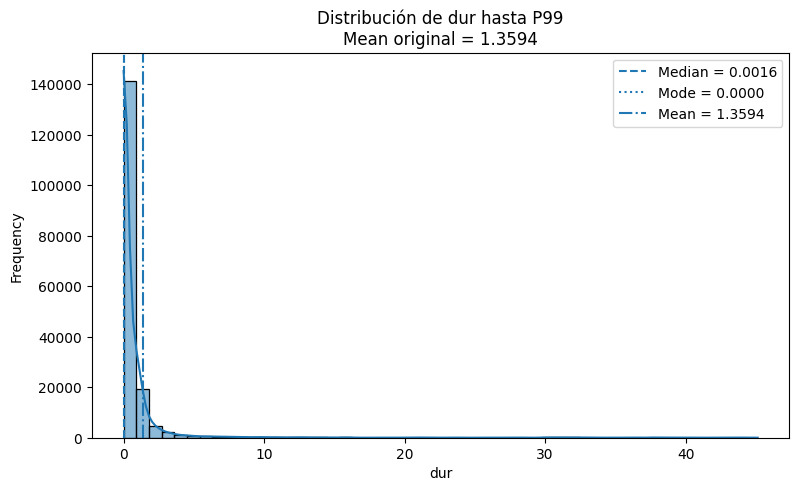

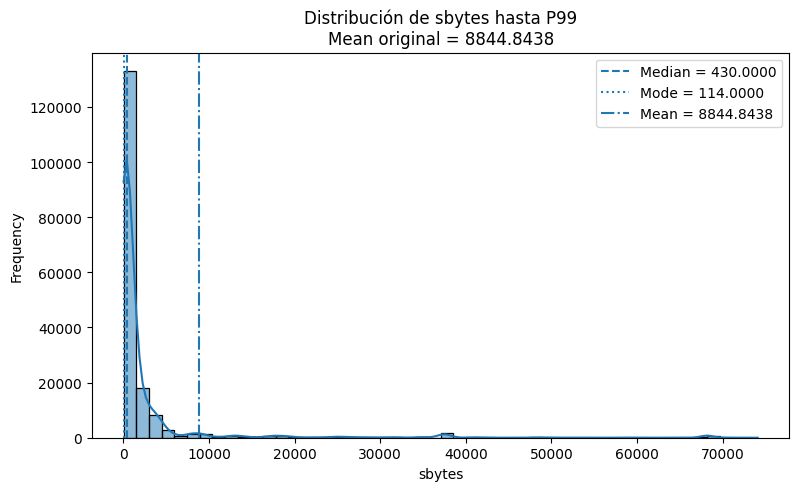

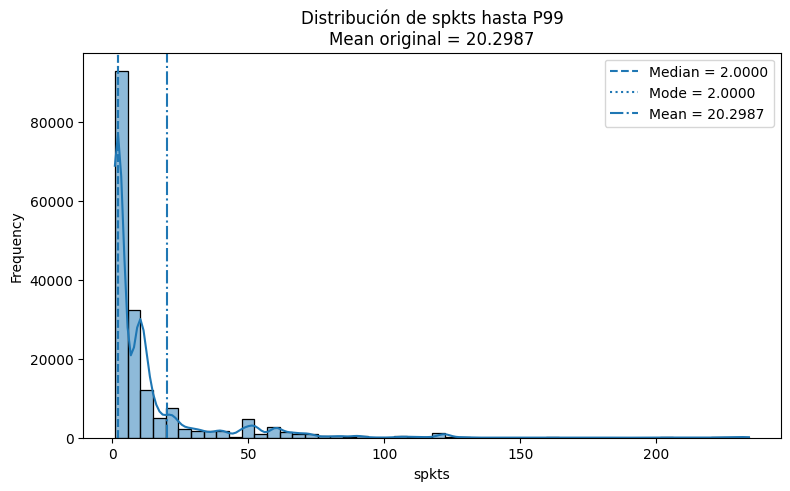

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_central_tendency(df, variable):

    mean_value = df[variable].mean()
    median_value = df[variable].median()
    mode_value = df[variable].mode().iloc[0]

    p99 = df[variable].quantile(0.99)

    data_plot = df.loc[
        df[variable] <= p99,
        variable
    ]

    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=data_plot,
        bins=50,
        kde=True
    )

    # Mediana
    plt.axvline(
        median_value,
        linestyle='--',
        label=f'Median = {median_value:.4f}'
    )

    # Moda
    plt.axvline(
        mode_value,
        linestyle=':',
        label=f'Mode = {mode_value:.4f}'
    )

    # Dibujar la media solo si aparece dentro del rango mostrado
    if mean_value <= p99:
        plt.axvline(
            mean_value,
            linestyle='-.',
            label=f'Mean = {mean_value:.4f}'
        )

    plt.title(
        f'Distribución de {variable} hasta P99\n'
        f'Mean original = {mean_value:.4f}'
    )

    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.legend()

    plt.show()


plot_central_tendency(df_clean, 'dur')
plot_central_tendency(df_clean, 'sbytes')
plot_central_tendency(df_clean, 'spkts')

Para facilitar la visualización de distribuciones altamente asimétricas, los histogramas se muestran hasta el percentil 99. Esta restricción se aplica únicamente a la visualización y no modifica ni elimina observaciones del dataset.


## 9. Medidas de dispersión
Rango, varianza, desviación estándar, cuartiles e IQR.

Las medidas de tendencia central permiten identificar valores representativos, pero no muestran qué tanto varían las observaciones.

Para analizar la dispersión de las variables seleccionadas se calculan:

- Rango

- Varianza

- Desviación estándar

- Primer cuartil (Q1)

- Tercer cuartil (Q3)

- Rango intercuartílico (IQR)

Estas medidas permiten identificar qué tan concentrados o dispersos están los datos y preparan el análisis posterior de posibles valores atípicos.

In [ ]:
dispersion = pd.DataFrame(
    index=analysis_vars
)

dispersion['Min'] = (
    df_clean[analysis_vars].min()
)

dispersion['Max'] = (
    df_clean[analysis_vars].max()
)

dispersion['Range'] = (
    dispersion['Max']
    - dispersion['Min']
)

dispersion['Variance'] = (
    df_clean[analysis_vars].var()
)

dispersion['Std'] = (
    df_clean[analysis_vars].std()
)

dispersion['Q1'] = (
    df_clean[analysis_vars].quantile(0.25)
)

dispersion['Q3'] = (
    df_clean[analysis_vars].quantile(0.75)
)

dispersion['IQR'] = (
    dispersion['Q3']
    - dispersion['Q1']
)

display(
    dispersion.round(4)
)

#Una tabla de resumen de la dispersion
print("\nSummary TAble")
dispersion_summary = dispersion[
    [
        'Range',
        'Variance',
        'Std',
        'IQR'
    ]
]

display(
    dispersion_summary.round(4)
)

,Min,Max,Range,Variance,Std,Q1,Q3,IQR
dur,0.0000,60.0000,60.0000,41.9936,6.4802,0.0000,0.6681,0.6681
spkts,1.0000,"9,616.0000","9,615.0000","18,738.2142",136.8876,2.0000,12.0000,10.0000
dpkts,0.0000,"10,974.0000","10,974.0000","12,156.8862",110.2583,0.0000,10.0000,10.0000
sbytes,28.0000,"12,965,233.0000","12,965,205.0000","30,543,030,430.8962","174,765.6443",114.0000,"1,418.0000","1,304.0000"
dbytes,0.0000,"14,655,550.0000","14,655,550.0000","20,636,534,268.1264","143,654.2177",0.0000,"1,102.0000","1,102.0000"
rate,0.0000,"1,000,000.0030","1,000,000.0030","27,357,483,674.6088","165,400.9785",32.7861,"125,000.0003","124,967.2142"
sload,0.0000,"5,988,000,256.0000","5,988,000,256.0000","35,478,527,840,430,560.0000","188,357,447.0002","13,053.3389","88,888,888.0000","88,875,834.6611"
dload,0.0000,"22,422,730.0000","22,422,730.0000","5,862,753,683,978.5283","2,421,312.3888",0.0000,"27,844.8711","27,844.8711"
tcprtt,0.0000,2.5189,2.5189,0.0063,0.0794,0.0000,0.0655,0.0655



Summary TAble


,Range,Variance,Std,IQR
dur,60.0000,41.9936,6.4802,0.6681
spkts,"9,615.0000","18,738.2142",136.8876,10.0000
dpkts,"10,974.0000","12,156.8862",110.2583,10.0000
sbytes,"12,965,205.0000","30,543,030,430.8962","174,765.6443","1,304.0000"
dbytes,"14,655,550.0000","20,636,534,268.1264","143,654.2177","1,102.0000"
rate,"1,000,000.0030","27,357,483,674.6088","165,400.9785","124,967.2142"
sload,"5,988,000,256.0000","35,478,527,840,430,560.0000","188,357,447.0002","88,875,834.6611"
dload,"22,422,730.0000","5,862,753,683,978.5283","2,421,312.3888","27,844.8711"
tcprtt,2.5189,0.0063,0.0794,0.0655


**Interpretación de las medidas de dispersión**

Las variables analizadas presentan distintos niveles de variabilidad. En varios casos se observa una diferencia considerable entre el rango total y el rango intercuartílico (IQR), lo que indica que la mayor parte de las observaciones se encuentra concentrada en un intervalo relativamente pequeño mientras existen registros con valores considerablemente superiores.

Este comportamiento es especialmente visible en variables como spkts, dpkts, sbytes, dbytes y dload. Por ejemplo, sbytes presenta un rango superior a 12 millones de bytes, mientras que el 50% central de los datos se encuentra dentro de un IQR de aproximadamente 1,304 bytes.

Estos resultados son consistentes con las diferencias observadas previamente entre media y mediana y sugieren distribuciones asimétricas y la presencia de posibles valores atípicos. Sin embargo, estos valores no serán considerados errores automáticamente, ya que en un contexto de ciberseguridad pueden representar comportamientos reales asociados a tráfico anómalo o malicioso.

En la siguiente sección se utilizará el método del rango intercuartílico y visualizaciones como boxplots para identificar y analizar formalmente estos valores extremos.


## 10. Distribuciones y outliers
Los valores extremos se estudian como observaciones potencialmente informativas, no como errores automáticos.

Las medidas de tendencia central y dispersión mostraron que varias variables presentan una fuerte asimetría y diferencias importantes entre el rango total y el rango intercuartílico.

En esta sección se identifican posibles valores atípicos utilizando el método del rango intercuartílico (IQR). Estos valores no se eliminarán automáticamente, ya que en un contexto de ciberseguridad pueden representar comportamientos reales o tráfico anómalo relevante.

In [ ]:
# Tabla outlier summary

outlier_results = []

for col in analysis_vars:

    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_mask = (
        (df_clean[col] < lower_limit) |
        (df_clean[col] > upper_limit)
    )

    outlier_count = outlier_mask.sum()

    outlier_percentage = (
        outlier_count / len(df_clean)
    ) * 100

    outlier_results.append({
        'Variable': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lower Limit': lower_limit,
        'Upper Limit': upper_limit,
        'Outliers': outlier_count,
        'Outlier %': outlier_percentage
    })

outlier_summary = pd.DataFrame(
    outlier_results
)

display(
    outlier_summary.round(4)
)

,Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,Outliers,Outlier %
0,dur,0.0000,0.6681,0.6681,-1.0021,1.6702,15741,8.9774
1,spkts,2.0000,12.0000,10.0000,-13.0000,27.0000,24675,14.0726
2,dpkts,0.0000,10.0000,10.0000,-15.0000,25.0000,20830,11.8797
3,sbytes,114.0000,"1,418.0000","1,304.0000","-1,842.0000","3,374.0000",22873,13.0449
4,dbytes,0.0000,"1,102.0000","1,102.0000","-1,653.0000","2,755.0000",28131,16.0436
5,rate,32.7861,"125,000.0003","124,967.2142","-187,418.0351","312,450.8215",17340,9.8893
6,sload,"13,053.3389","88,888,888.0000","88,875,834.6611","-133,300,698.6528","222,202,639.9917",13518,7.7095
7,dload,0.0000,"27,844.8711","27,844.8711","-41,767.3066","69,612.1777",38143,21.7536
8,tcprtt,0.0000,0.0655,0.0655,-0.0982,0.1637,15878,9.0555


### Decisión sobre los valores atípicos

Los valores identificados mediante IQR se consideran candidatos a outliers, no errores confirmados.

Debido a que el objetivo es analizar tráfico de red y distinguir comportamientos normales de maliciosos, los valores extremos pueden contener informacion retevante para la detección de actividad anomala.

Por esta razon, los outliers conservan en el dataset y se analizan posteriormente segun la clase de trafico.

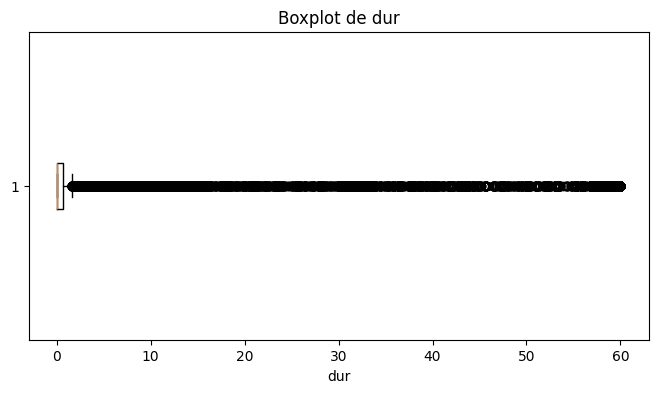

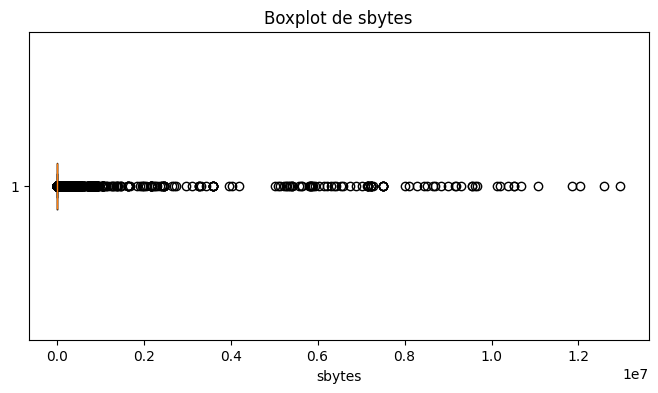

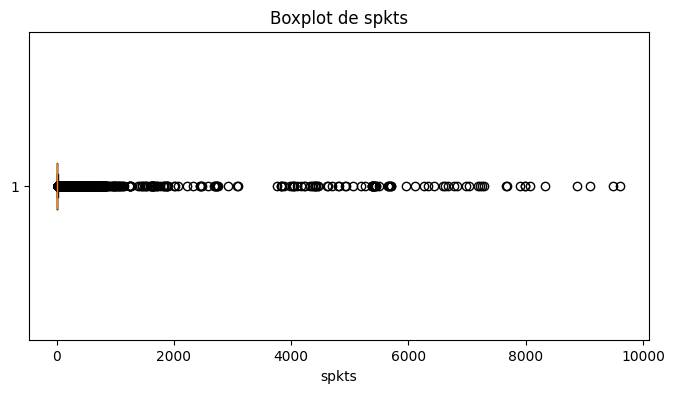

In [ ]:
'''
Box plots selecicionando las 3 variables mas significativas
+ spkts
+ dur
+ sbytes
'''

def plot_boxplot(df, variable, use_log=False):

    data = df[variable].dropna()

    if use_log:
        data = np.log1p(data)
        x_label = f'log(1 + {variable})'
        title = f'Boxplot de log(1 + {variable})'
    else:
        x_label = variable
        title = f'Boxplot de {variable}'

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        data,
        vert=False
    )

    plt.title(title)
    plt.xlabel(x_label)

    plt.show()


plot_boxplot(df_clean, 'dur')
plot_boxplot(df_clean, 'sbytes')
plot_boxplot(df_clean, 'spkts')

El metodo IQR identificó una proporción relevante de valores atípicos en varias variables. dload presentó la mayor proporción de outliers, con aproximadamente 21.75%, seguido por dbytes, spkts y sbytes.

Los boxplots confirman que gran parte de las observaciones se concentra en valores relativamente bajos, mientras existe una cantidad significativa de registros con valores considerablemente mayores.

Sin embargo, estos valores no se eliminaron, ya que en un contexto de ciberseguridad pueden representar comportamiento extremo o actividad potencialmente maliciosa. Por esta razon, se conservarán para comparar posteriormente su comportamiento entre trafico normal y trafico de ataque.


## 11. Comparación: tráfico normal vs. malicioso

Para identificar diferencias descriptivas entre ambos tipos de tráfico, se comparan las variables seleccionadas según la variable `label`.

Se analizarán medidas como media, mediana y desviación estándar para observar si el comportamiento de las conexiones cambia entre tráfico normal y tráfico malicioso.

In [ ]:
# Analysis de variables: se usara la mediana
median_comparison = (
    df_clean
    .groupby('label')[analysis_vars]
    .median()
    .T
)

median_comparison.columns = [
    'Normal',
    'Attack'
]

median_comparison['Difference'] = (
    median_comparison['Attack']
    - median_comparison['Normal']
)

display(
    median_comparison.round(4)
)

,Normal,Attack,Difference
dur,0.0386,0.0000,-0.0386
spkts,12.0000,2.0000,-10.0000
dpkts,10.0000,0.0000,-10.0000
sbytes,"1,470.0000",200.0000,"-1,270.0000"
dbytes,"1,112.0000",0.0000,"-1,112.0000"
rate,"1,382.2566","111,111.1072","109,728.8506"
sload,"431,327.6562","50,666,664.0000","50,235,336.3438"
dload,"336,120.6406",0.0000,"-336,120.6406"
tcprtt,0.0006,0.0000,-0.0006


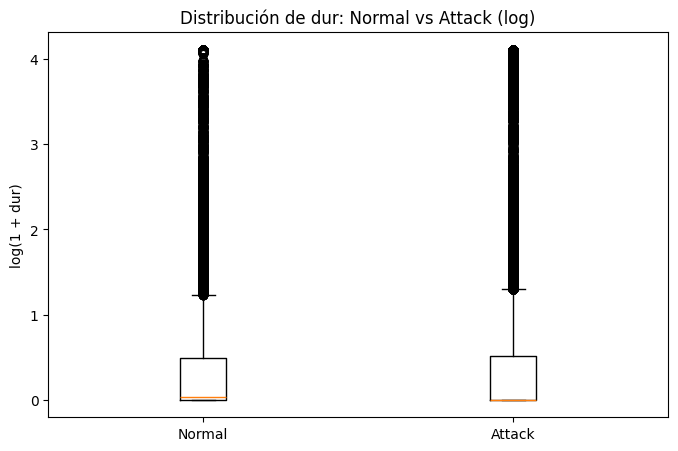

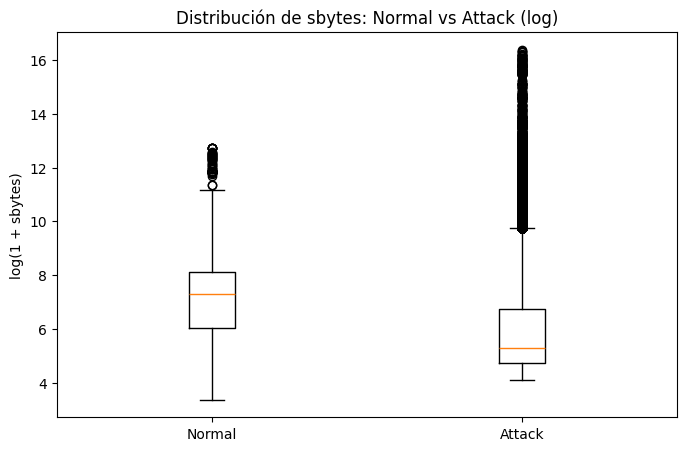

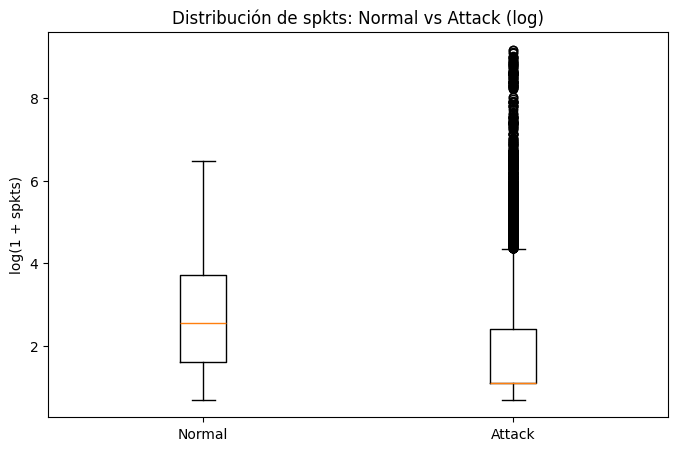

In [ ]:
'''
Box plots selecicionando las 3 variables mas significativas
+ spkts
+ dur
+ sbytes
'''

def plot_boxplot_by_label(df, variable, use_log=False):

    normal = df.loc[
        df['label'] == 0,
        variable
    ].dropna()

    attack = df.loc[
        df['label'] == 1,
        variable
    ].dropna()

    if use_log:
        normal = np.log1p(normal)
        attack = np.log1p(attack)

        y_label = f'log(1 + {variable})'

        title = (
            f'Distribución de {variable}: '
            'Normal vs Attack (log)'
        )

    else:
        y_label = variable

        title = (
            f'Distribución de {variable}: '
            'Normal vs Attack'
        )

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        [normal, attack],
        tick_labels=[
            'Normal',
            'Attack'
        ]
    )

    plt.title(title)
    plt.ylabel(y_label)

    plt.show()

plot_boxplot_by_label(df_clean, 'dur', use_log=True)

plot_boxplot_by_label(df_clean, 'sbytes', use_log=True)

plot_boxplot_by_label(df_clean, 'spkts', use_log=True)


* **dur — duración de las conexiones:** El boxplot de dur muestra una fuerte concentración de conexiones con duraciones bajas y una gran cantidad de observaciones por encima del rango intercuartílico. Esto confirma la presencia de una distribución asimétrica hacia valores altos y de numerosos valores considerados atípicos según el criterio IQR. Estos valores no se eliminan, ya que podrían representar comportamientos relevantes dentro del tráfico de red.
* **sbytes — bytes enviados desde el origen:** El boxplot de sbytes evidencia que la mayoría de las conexiones transfiere cantidades relativamente pequeñas de datos desde el origen, mientras que un conjunto menor presenta volúmenes considerablemente mayores. La diferencia entre el rango central y los valores extremos refleja una alta dispersión y una fuerte asimetría en esta variable.
* **spkts — paquetes enviados desde el origen:** El boxplot de spkts muestra que la mayor parte de las conexiones utiliza un número reducido de paquetes, mientras existen observaciones con cantidades de paquetes muy superiores. Este patrón coincide con la diferencia observada previamente entre la media y la mediana y sugiere una cola derecha pronunciada.

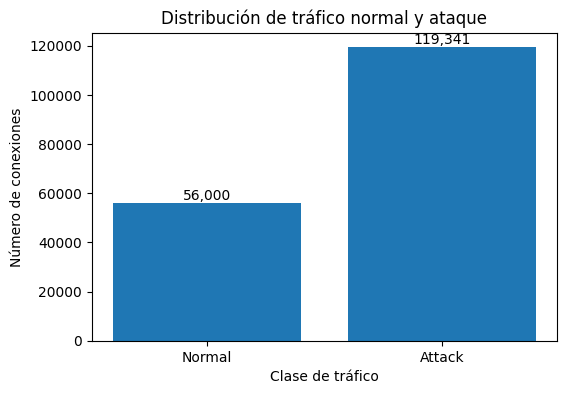

In [ ]:
# Distribuciony numero de conexiones
label_counts = (
    df_clean['label']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    ['Normal', 'Attack'],
    label_counts.values
)

plt.title('Distribución de tráfico normal y ataque')
plt.xlabel('Clase de tráfico')
plt.ylabel('Número de conexiones')

for bar, value in zip(bars, label_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:,}',
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
#Comparacion categorica de ataques

attack_category_comparison = (
    df_clean
    .groupby('attack_cat')[analysis_vars]
    .median()
)

display(
    attack_category_comparison.round(4)
)

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,tcprtt
attack_cat,,,,,,,,,
analysis,0.0000,2.0000,0.0000,200.0000,0.0000,"111,111.1072","88,888,888.0000",0.0000,0.0000
backdoor,0.0000,2.0000,0.0000,200.0000,0.0000,"111,111.1072","88,888,888.0000",0.0000,0.0000
dos,0.0000,2.0000,0.0000,200.0000,0.0000,"111,111.1072","88,888,888.0000",0.0000,0.0000
exploits,0.4865,10.0000,8.0000,828.0000,354.0000,57.5412,"29,487.1699","3,664.3191",0.0567
fuzzers,0.6174,10.0000,6.0000,914.0000,268.0000,32.3413,"16,591.7930","2,511.3765",0.1127
generic,0.0000,2.0000,0.0000,114.0000,0.0000,"125,000.0003","57,000,000.0000",0.0000,0.0000
normal,0.0386,12.0000,10.0000,"1,470.0000","1,112.0000","1,382.2566","431,327.6562","336,120.6406",0.0006
reconnaissance,0.1873,10.0000,0.0000,564.0000,0.0000,78.9706,"33,017.7734",0.0000,0.0000
shellcode,0.0000,2.0000,0.0000,536.0000,0.0000,"47,619.0480","36,631,580.0000",0.0000,0.0000


En conclusion con esta seccion podemos evidenciar que la comparación entre tráfico normal y tráfico de ataque muestra diferencias descriptivas en varias características de red. Las medianas, la dispersión y la forma de las distribuciones no son idénticas entre ambos grupos, lo que sugiere que variables como duración, cantidad de paquetes y volumen de bytes pueden aportar información relevante para distinguir comportamientos normales de maliciosos. Sin embargo, estas diferencias son descriptivas y no implican causalidad ni garantizan por sí solas la clasificación de una conexión.

## 12. Comparación por categorías de ataque
Utilizar `attack_cat` para describir diferencias entre familias.

Después de comparar tráfico normal y malicioso de forma general, se analizan las principales categorías de `attack_cat` para identificar diferencias descriptivas entre distintos tipos de tráfico.

El objetivo no es determinar causalidad ni construir todavía un modelo predictivo, sino observar si ciertas características de red presentan comportamientos distintos entre categorías.

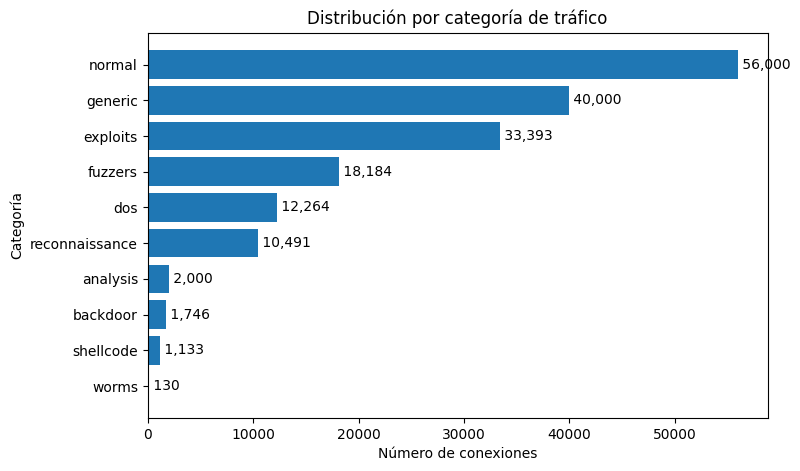

In [ ]:
# Distribución de categorías

attack_counts = (
    df_clean['attack_cat']
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(8, 5))

bars = plt.barh(
    attack_counts.index,
    attack_counts.values
)

plt.title('Distribución por categoría de tráfico')
plt.xlabel('Número de conexiones')
plt.ylabel('Categoría')

for bar, value in zip(bars, attack_counts.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f' {value:,}',
        va='center'
    )

plt.show()

La distribución por attack_cat muestra que las categorías no están igualmente representadas. normal, generic y exploits concentran una parte importante de los registros, mientras categorías como worms, shellcode y backdoor tienen una representación mucho menor. Este desbalance debe considerarse al interpretar comparaciones entre categorías.

In [ ]:
# Comparación estadística por categoría
#Mediana
attack_category_median = (
    df_clean
    .groupby('attack_cat')[analysis_vars]
    .median()
)

display(
    attack_category_median.round(4)
)


# Medi
attack_category_mean = (
    df_clean
    .groupby('attack_cat')[analysis_vars]
    .mean()
)

display(
    attack_category_mean.round(4)
)

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,tcprtt
attack_cat,,,,,,,,,
analysis,0.0000,2.0000,0.0000,200.0000,0.0000,"111,111.1072","88,888,888.0000",0.0000,0.0000
backdoor,0.0000,2.0000,0.0000,200.0000,0.0000,"111,111.1072","88,888,888.0000",0.0000,0.0000
dos,0.0000,2.0000,0.0000,200.0000,0.0000,"111,111.1072","88,888,888.0000",0.0000,0.0000
exploits,0.4865,10.0000,8.0000,828.0000,354.0000,57.5412,"29,487.1699","3,664.3191",0.0567
fuzzers,0.6174,10.0000,6.0000,914.0000,268.0000,32.3413,"16,591.7930","2,511.3765",0.1127
generic,0.0000,2.0000,0.0000,114.0000,0.0000,"125,000.0003","57,000,000.0000",0.0000,0.0000
normal,0.0386,12.0000,10.0000,"1,470.0000","1,112.0000","1,382.2566","431,327.6562","336,120.6406",0.0006
reconnaissance,0.1873,10.0000,0.0000,564.0000,0.0000,78.9706,"33,017.7734",0.0000,0.0000
shellcode,0.0000,2.0000,0.0000,536.0000,0.0000,"47,619.0480","36,631,580.0000",0.0000,0.0000


,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,tcprtt
attack_cat,,,,,,,,,
analysis,1.8017,6.1125,2.5940,"1,029.6380",361.1510,"140,031.1187","111,326,829.8002","2,999.1332",0.0454
backdoor,2.6588,7.5630,1.6667,"1,834.5830",341.0962,"147,399.7969","119,315,006.0373","2,867.0267",0.0204
dos,2.5749,22.5246,18.6890,"17,272.0114","18,969.2245","151,574.7831","126,281,382.6454","15,009.7586",0.0220
exploits,2.2586,32.7175,22.1618,"28,344.3180","16,702.7765","73,646.7597","65,310,277.4090","53,272.9959",0.0735
fuzzers,2.8585,14.4220,6.1967,"7,286.6963",520.6022,"67,191.4415","134,145,333.4488","3,170.8371",0.1011
generic,0.0612,2.4728,0.9350,396.0432,"1,078.6004","216,796.9616","101,219,111.4991","2,212.9649",0.0016
normal,1.0172,30.7255,38.0577,"4,105.7029","31,049.4631","13,799.3121","23,170,702.7308","2,062,949.2437",0.0319
reconnaissance,1.0601,7.0571,5.2765,772.1401,"2,291.0492","103,843.8829","73,682,736.3579","2,384.2411",0.0601
shellcode,0.3670,5.9329,3.2657,529.7440,145.3398,"100,977.7754","132,999,703.3126","2,305.3282",0.0626


In [ ]:
'''
Tabla compacta teniendo en cuenta 4 variables importantes para el analisis
'''

category_vars = [
    'dur',
    'spkts',
    'sbytes',
    'dbytes'
]

category_summary = (
    df_clean
    .groupby('attack_cat')[category_vars]
    .median()
)

display(
    category_summary.round(4)
)

,dur,spkts,sbytes,dbytes
attack_cat,,,,
analysis,0.0000,2.0000,200.0000,0.0000
backdoor,0.0000,2.0000,200.0000,0.0000
dos,0.0000,2.0000,200.0000,0.0000
exploits,0.4865,10.0000,828.0000,354.0000
fuzzers,0.6174,10.0000,914.0000,268.0000
generic,0.0000,2.0000,114.0000,0.0000
normal,0.0386,12.0000,"1,470.0000","1,112.0000"
reconnaissance,0.1873,10.0000,564.0000,0.0000
shellcode,0.0000,2.0000,536.0000,0.0000


* dur → tiempo de conexión
* spkts → paquetes enviados
* sbytes → bytes enviados
* dbytes → bytes recibidos

Nos dan tiempo + paquetes + tráfico bidireccional. Por eso mismo se escogen eestas

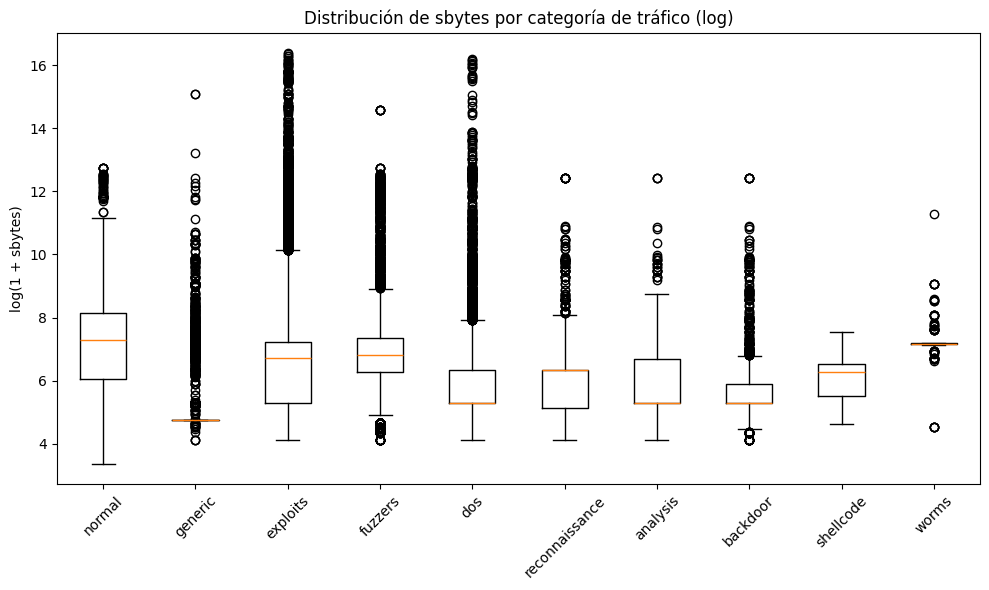

In [ ]:
'''
Vizualiacion de las variables seleccionadas, esta ves se usara una variable comparar categorías con boxplot logaritmico
'''

categories = (
    df_clean['attack_cat']
    .value_counts()
    .index
)

data_by_category = [
    np.log1p(
        df_clean.loc[
            df_clean['attack_cat'] == category,
            'sbytes' #Aqui puedes selecionear la varible/ categoria a comparar
        ].dropna()
    )
    for category in categories
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data_by_category,
    tick_labels=categories,
    vert=True
)

plt.title(
    'Distribución de sbytes por categoría de tráfico (log)' #No olvides cambiar las legend
)

plt.ylabel('log(1 + sbytes)') #Aqui tambien esta en lel label
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 13. Hallazgos principales



1. Varias variables numéricas presentan distribuciones fuertemente asimétricas, evidenciadas por diferencias importantes entre media y mediana.

2. Variables como duración, paquetes, bytes y carga presentan una dispersión elevada y una cantidad importante de valores atípicos.

3. El tráfico normal y el tráfico de ataque presentan diferencias descriptivas en varias de estas variables, tanto en tendencia central como en dispersión.

4. Las categorías de ataque no presentan comportamientos idénticos, lo que sugiere que diferentes tipos de actividad maliciosa pueden generar patrones de tráfico distintos.


**Pregunta deinvestigacion** -> El analisis descriptivo sugiere que variables relacionadas con duración, cantidad de paquetes, volumen de bytes y carga de tráfico contienen información útil para diferenciar patrones de tráfico normal y malicioso. Sin embargo, ninguna variable individual permite afirmar por sí sola si una conexión corresponde a un ataque. Estas características deben analizarse de manera conjunta y posteriormente evaluarse mediante modelos predictivos.

**limitaciones:** Este analisis es descriptivo y se basa en la partición de entrenamiento del dataset. Las diferencias observadas no implican causalidad ni garantizan capacidad predictiva. Además, algunas categorías de ataque presentan pocos registros, por lo que sus resultados deben interpretarse con precaución.

**En el area de Ciberseguridad:** En un contexto de ciberseguridad, este tipo de análisis puede utilizarse como una etapa inicial de exploración para identificar variables relevantes, comprender patrones de tráfico y preparar datos para sistemas de detección de intrusiones o clasificación automática de amenazas.



---


# MODULO 3 — reservado


---



**Regla:** el testing set se mantiene separado hasta esta etapa.

## 14. Visualización y storytelling


## 15. Preparación para modelado


## 16. Modelo(s)


## 17. Evaluación sobre testing set


## 18. Conclusiones finales




---


#**Referencias del dataset**


---


La documentación incluida con UNSW-NB15 solicita citar:

- Moustafa, N., & Slay, J. (2015). *UNSW-NB15: a comprehensive data set for network intrusion detection systems (UNSW-NB15 network data set).* MilCIS.
- Moustafa, N., & Slay, J. (2016). *The evaluation of Network Anomaly Detection Systems: Statistical analysis of the UNSW-NB15 data set and the comparison with the KDD99 data set.* Information Security Journal: A Global Perspective.


---


* Moustafa, N., & Slay, J. (2015).
   UNSW-NB15: A comprehensive data set for network intrusion detection systems
   (UNSW-NB15 network data set).
   2015 Military Communications and Information Systems Conference (MilCIS), 1–6.
   https://doi.org/10.1109/MilCIS.2015.7348942

* Moustafa, N., & Slay, J. (2016).
   The evaluation of Network Anomaly Detection Systems:
   Statistical analysis of the UNSW-NB15 data set and the comparison with the KDD99 data set.
   Information Security Journal: A Global Perspective, 25(1–3), 18–31.
   https://doi.org/10.1080/19393555.2015.1125974

* University of New South Wales.
   The UNSW-NB15 Dataset.
   UNSW Research.

* NIST/SEMATECH.
   Engineering Statistics Handbook:
   What are outliers in the data?

* The pandas development team.
   pandas documentation.

* NumPy Developers.
   NumPy documentation.

* Matplotlib Development Team.
   Matplotlib documentation: boxplot.
